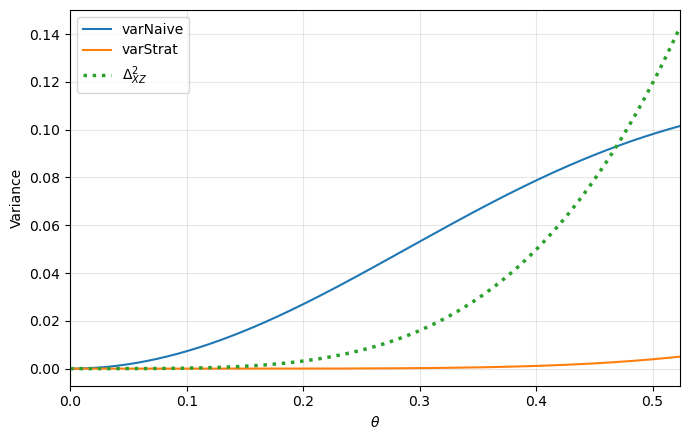

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def var_naive(theta):
    s = np.sin(theta)
    c = np.cos(theta)
    return (s**2 / 64) * (
        119*c**4 - 56*c**3 - 46*c**2 + 8*c + 23
    )

def var_strat(theta):
    s = np.sin(theta)
    c = np.cos(theta)
    return (s**2 * (1 - c)**2 / 12) * (
        7*c**2 + 6*c + 3
    )

def delta_xz_squared(theta):

    x = np.sin(theta / 2)**4

    return 32 * x * (1 - x)

# Plot range: t from 0 to pi/4
theta_range = [0, np.pi/6]
theta = np.linspace(*theta_range, 500)

plt.figure(figsize=(7, 4.5))

plt.plot(theta, var_naive(theta), label="varNaive")
plt.plot(theta, var_strat(theta), label="varStrat")
plt.plot(theta, delta_xz_squared(theta), ":", linewidth=2.5, label=r"$\Delta_{XZ}^2$")

plt.xlabel(r"$\theta$")
plt.ylabel("Variance")
plt.xlim(*theta_range)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("variance_m3_toy_example.png", dpi=300)
plt.show()

In [2]:
def c(theta):
    return np.cos(theta)
def s(theta):
    return np.sin(theta)

# bloch sphere rotations
def rotation_x(theta):
    return np.array([
        [1, 0, 0],
        [0, c(theta), -s(theta)],
        [0, s(theta), c(theta)]
    ])
def rotation_z(theta):
    return np.array([
        [c(theta), -s(theta), 0],
        [s(theta), c(theta), 0],
        [0, 0, 1]
    ])

def G_inf(t, Delta):
    '''
    QPD re-weighting factor
    \[
    G_\infty=\exp\!\left(4t\tan(\Delta/2)\right).
    \]
    '''
    return np.exp(4 * t * np.tan(Delta / 2))

# exact expected values for Z and Y observables
def exact_z(t):
    return (1+c(2*np.sqrt(2)*t))/2
def exact_y(t):
    return -1/np.sqrt(2)*s(2*np.sqrt(2)*t)

In [3]:
# Naive variance from the marked Poisson process moments (LaTeX section)
import numpy as np

def _expm(A: np.ndarray) -> np.ndarray:
    """Matrix exponential with SciPy if available, otherwise eig-based (small matrices)."""
    try:
        from scipy.linalg import expm  # type: ignore
        return expm(A)
    except Exception:
        w, V = np.linalg.eig(A)
        Vinv = np.linalg.inv(V)
        return (V @ np.diag(np.exp(w)) @ Vinv)

def _real_if_close(x, tol=1e-10):
    x = np.asarray(x)
    if np.iscomplexobj(x):
        if np.max(np.abs(np.imag(x))) < tol:
            return np.real(x)
    return x

def naive_moments_and_variance(t: float, Delta: float, o: np.ndarray, r: np.ndarray):
    """Return (E[Y], E[Y^2], Var_naive) for the TE-PAI estimator in Bloch form."""
    I3 = np.eye(3)
    I9 = np.eye(9)

    # Event rotations (Bloch sphere) and signs epsilon
    R_x_plus = rotation_x(+Delta)
    R_z_minus = rotation_z(-Delta)
    R_x3 = rotation_x(np.pi)
    R_z3 = rotation_z(np.pi)

    # eps=+1 for type-2 events, eps=-1 for type-3 events
    epsilons = [+1, +1, -1, -1]

    # Event rates kappa
    kappa_type2 = 2.0 / np.sin(Delta)
    kappa_type3 = np.tan(Delta / 2.0)
    kappas = [kappa_type2, kappa_type2, kappa_type3, kappa_type3]
    Rs = [R_x_plus, R_z_minus, R_x3, R_z3]

    # Global weight G_infty
    G = G_inf(t, Delta)

    # First moment: E[Y] = G * o^T exp[t Σ kappa (epsilon R - I)] r
    A1 = np.zeros((3, 3), dtype=float)
    for kappa, eps, R in zip(kappas, epsilons, Rs):
        A1 += kappa * (eps * R - I3)
    EY = float(_real_if_close(o.T @ _expm(t * A1) @ r)) * G

    # Second moment: E[Y^2] = G^2 * (o⊗o)^T exp[t Σ kappa (R⊗R - I)] (r⊗r)
    A2 = np.zeros((9, 9), dtype=float)
    for kappa, R in zip(kappas, Rs):
        A2 += kappa * (np.kron(R, R) - I9)
    oo = np.kron(o, o)
    rr = np.kron(r, r)
    EY2 = float(_real_if_close(oo.T @ _expm(t * A2) @ rr)) * (G ** 2)

    var = EY2 - EY ** 2
    return _real_if_close(EY), _real_if_close(EY2), _real_if_close(var)

# Basis Bloch vectors
e_x = np.array([1.0, 0.0, 0.0])
e_y = np.array([0.0, 1.0, 0.0])
e_z = np.array([0.0, 0.0, 1.0])

# Example from the LaTeX: t=1/2, Delta=pi/4, input rho=|0><0| => r=e_z
t = 0.5
Delta = np.pi / 4
r = e_z

print("Parameters:")
print(f"  t     = {t}")
print(f"  Delta = {Delta} (= pi/4)")
print(f"  G_inf = {G_inf(t, Delta)}")
Lambda = 2 * t * (3 - np.cos(Delta)) / np.sin(Delta)
print(f"  Lambda (total event rate) = {Lambda}")

for name, o in [("Z", e_z), ("Y", e_y)]:
    EY, EY2, var = naive_moments_and_variance(t, Delta, o=o, r=r)
    print()
    print(f"Observable O={name}:")
    print(f"  E[Y]      = {EY}")
    print(f"  E[Y^2]    = {EY2}")
    print(f"  Var_naive = {var}")

# compare against exact values
print()
print("Exact expected values:")
print(f"  E[Z] = {exact_z(t)}")
print(f"  E[Y] = {exact_y(t)}")

Parameters:
  t     = 0.5
  Delta = 0.7853981633974483 (= pi/4)
  G_inf = 2.2897144712443587
  Lambda (total event rate) = 3.2426406871192857

Observable O=Z:
  E[Y]      = 0.5779718473826873
  E[Y^2]    = 2.666748492906713
  Var_naive = 2.3326970365397566

Observable O=Y:
  E[Y]      = -0.6984559986366088
  E[Y^2]    = 1.730229212681282
  Var_naive = 1.2423884306498194

Exact expected values:
  E[Z] = 0.5779718473826871
  E[Y] = -0.6984559986366083


In [4]:
# Residual variance after conditioning on the marked counts N = (N_{x+}, N_{z-}, N_{x3}, N_{z3}). 
# the important residual is E[Var(Y|N)], which is the contribution to Var(Y) that remains even after conditioning on the full marked count information. We will compute this residual truncated to |N|<=M for some cutoff M, and also compute tail bounds for the contribution from |N|>M.
import math
import numpy as np

def _log_poisson_pmf(n: int, lam: float) -> float:
    # log( e^{-lam} lam^n / n! )
    return -lam + n * math.log(lam) - math.lgamma(n + 1)

def _log_product_poisson_pmf(n_vec, lam_vec) -> float:
    return sum(_log_poisson_pmf(int(n), float(lam)) for n, lam in zip(n_vec, lam_vec))

def _poisson_cdf_truncated(M: int, lam: float) -> float:
    """Return P(K <= M) for K~Poisson(lam) via stable recurrence."""
    if M < 0:
        return 0.0
    p = math.exp(-lam)  # k=0
    s = p
    for k in range(0, M):
        p *= lam / (k + 1)
        s += p
    return min(1.0, max(0.0, s))

def compute_Rbar_Qbar_up_to_M(M: int, Rs: list[np.ndarray]):
    """Compute dicts for Rbar(n) and Qbar(n) for all n with |n|<=M.

    n is a 4-tuple (n_xplus, n_zminus, n_x3, n_z3).
    """
    I3 = np.eye(3)
    I9 = np.eye(9)
    Rbar: dict[tuple[int, int, int, int], np.ndarray] = {(0, 0, 0, 0): I3}
    Qbar: dict[tuple[int, int, int, int], np.ndarray] = {(0, 0, 0, 0): I9}

    kron_Rs = [np.kron(R, R) for R in Rs]

    # Build in increasing total count so dependencies are already computed
    for m in range(1, M + 1):
        for n0 in range(m + 1):
            for n1 in range(m - n0 + 1):
                for n2 in range(m - n0 - n1 + 1):
                    n3 = m - n0 - n1 - n2
                    n = (n0, n1, n2, n3)
                    denom = float(m)

                    R_acc = np.zeros((3, 3), dtype=float)
                    Q_acc = np.zeros((9, 9), dtype=float)
                    for a, na in enumerate(n):
                        if na == 0:
                            continue
                        prev = list(n)
                        prev[a] -= 1
                        prev_t = tuple(prev)
                        w = na / denom
                        R_acc += w * (Rs[a] @ Rbar[prev_t])
                        Q_acc += w * (kron_Rs[a] @ Qbar[prev_t])

                    Rbar[n] = R_acc
                    Qbar[n] = Q_acc

    return Rbar, Qbar

def marked_count_residual_variance(t: float, Delta: float, o: np.ndarray, r: np.ndarray, M: int):
    """Compute truncated residual E[Var(Y|N)] over |N|<=M plus tail bounds."""
    # Event rotations in the order: (x_+, z_-, x_3, z_3)
    Rs = [
        rotation_x(+Delta),
        rotation_z(-Delta),
        rotation_x(np.pi),
        rotation_z(np.pi),
    ]

    # Rates (means) for the independent Poisson marked counts
    kappa_type2 = 2.0 / np.sin(Delta)
    kappa_type3 = np.tan(Delta / 2.0)
    kappas = [kappa_type2, kappa_type2, kappa_type3, kappa_type3]
    lams = [t * k for k in kappas]
    Lam_total = sum(lams)  # mean of |N|
    G = float(G_inf(t, Delta))

    Rbar, Qbar = compute_Rbar_Qbar_up_to_M(M, Rs)

    oo = np.kron(o, o)
    rr = np.kron(r, r)

    residual_trunc = 0.0
    mu2_avg_trunc = 0.0
    mass_trunc = 0.0

    # Sum over all n with |n|<=M (already enumerated by our dict keys)
    for n, Rn in Rbar.items():
        # product-Poisson probability
        logp = _log_product_poisson_pmf(n, lams)
        p = math.exp(logp)
        mass_trunc += p

        sign = -1.0 if ((n[2] + n[3]) % 2 == 1) else 1.0
        mu_n = G * sign * float(o.T @ Rn @ r)
        nu_n = (G ** 2) * float(oo.T @ Qbar[n] @ rr)
        sigma2_n = nu_n - mu_n ** 2

        residual_trunc += p * sigma2_n
        mu2_avg_trunc += p * (mu_n ** 2)

    # Tail probabilities (two ways: exact from truncation mass, and via Poisson(|N|) )
    tail_mass_from_sum = max(0.0, 1.0 - mass_trunc)
    tail_mass_poisson = max(0.0, 1.0 - _poisson_cdf_truncated(M, Lam_total))

    # The LaTeX tail bound: |Y|<=G => tail residual contribution <= G^2 * P(|N|>M)
    tail_bound_sum = (G ** 2) * tail_mass_from_sum
    tail_bound_poisson = (G ** 2) * tail_mass_poisson

    return {
        "residual_trunc": residual_trunc,
        "mass_trunc": mass_trunc,
        "tail_mass_from_sum": tail_mass_from_sum,
        "tail_mass_poisson": tail_mass_poisson,
        "tail_bound_sum": tail_bound_sum,
        "tail_bound_poisson": tail_bound_poisson,
        "mu2_avg_trunc": mu2_avg_trunc,
        "Lam_total": Lam_total,
        "G": G,
    }

# Demo at the same parameter point as before
t = 0.5
Delta = np.pi / 4
r = e_z
observables = [("Z", e_z), ("Y", e_y)]
Ms = [12, 15]

for obs_name, o in observables:
    EY0, EY2_0, var0 = naive_moments_and_variance(t, Delta, o=o, r=r)
    print()
    print("=" * 72)
    print(f"Observable O={obs_name}")
    print("Unconditional (naive) moments:")
    print(f"  E[Y]      = {EY0}")
    print(f"  E[Y^2]    = {EY2_0}")
    print(f"  Var(Y)    = {var0}")

    for M in Ms:
        out = marked_count_residual_variance(t, Delta, o=o, r=r, M=M)
        residual = out["residual_trunc"]
        tail_bound = out["tail_bound_poisson"]
        # Law of total variance check (truncated): Var(Y) = E[Var(Y|N)] + Var(E[Y|N])
        var_cond_mean_trunc = out["mu2_avg_trunc"] - (EY0 ** 2)
        print()
        print(f"Marked-count residual with cutoff M={M}:")
        print(f"  sum_{{|n|<=M}} p_n = {out['mass_trunc']}")
        print(f"  E[Var(Y|N)] (trunc) = {residual}")
        print(f"  Tail bound G^2 P(|N|>M) = {tail_bound}")
        print(f"  Var(E[Y|N]) (trunc) = {var_cond_mean_trunc}")
        print(f"  (Var split, trunc) = {residual + var_cond_mean_trunc}")


Observable O=Z
Unconditional (naive) moments:
  E[Y]      = 0.5779718473826873
  E[Y^2]    = 2.666748492906713
  Var(Y)    = 2.3326970365397566

Marked-count residual with cutoff M=12:
  sum_{|n|<=M} p_n = 0.9999644252801736
  E[Var(Y|N)] (trunc) = 0.17195108635010115
  Tail bound G^2 P(|N|>M) = 0.00018651086930706595
  Var(E[Y|N]) (trunc) = 2.1606840441735744
  (Var split, trunc) = 2.3326351305236757

Marked-count residual with cutoff M=15:
  sum_{|n|<=M} p_n = 0.9999996563280947
  E[Var(Y|N)] (trunc) = 0.17200680749267
  Tail bound G^2 P(|N|>M) = 1.8018004083732013e-06
  Var(E[Y|N]) (trunc) = 2.1606896274071072
  (Var split, trunc) = 2.3326964348997774

Observable O=Y
Unconditional (naive) moments:
  E[Y]      = -0.6984559986366088
  E[Y^2]    = 1.730229212681282
  Var(Y)    = 1.2423884306498194

Marked-count residual with cutoff M=12:
  sum_{|n|<=M} p_n = 0.9999644252801736
  E[Var(Y|N)] (trunc) = 0.5159265277259666
  Tail bound G^2 P(|N|>M) = 0.00018651086930706595
  Var(E[Y|N]) (

In [5]:
# Type-count residual variance: conditioning on S=(N_{+,2}^{tot}, N_{-,2}^{tot}, N_3^{tot})
# where N_{+,2}^{tot}=N_{x+}, N_{-,2}^{tot}=N_{z-}, N_3^{tot}=N_{x3}+N_{z3}, and the split is Binomial(n3, 1/2).
import math
import numpy as np

def _log_binom_pmf(k: int, n: int, p: float) -> float:
    if k < 0 or k > n:
        return float("-inf")
    if p <= 0.0:
        return 0.0 if k == 0 else float("-inf")
    if p >= 1.0:
        return 0.0 if k == n else float("-inf")
    # log( nCk p^k (1-p)^(n-k) )
    return (
        math.lgamma(n + 1) - math.lgamma(k + 1) - math.lgamma(n - k + 1)
        + k * math.log(p) + (n - k) * math.log(1.0 - p)
    )

def type_count_residual_variance(t: float, Delta: float, o: np.ndarray, r: np.ndarray, M: int):
    """Compute truncated residual E[Var(Y|S)] over n_+ + n_- + n_3 <= M plus tail bounds.

    Uses the LaTeX formulas: mu_s and nu_s average over the Binomial split of type-3 events.
    """
    # Event rotations in the order: (x_+, z_-, x_3, z_3)
    Rs = [
        rotation_x(+Delta),
        rotation_z(-Delta),
        rotation_x(np.pi),
        rotation_z(np.pi),
    ]
    G = float(G_inf(t, Delta))
    sign3 = lambda n3: (-1.0 if (n3 % 2 == 1) else 1.0)

    # Means for the independent Poisson type counts
    lam_plus = 2.0 * t / np.sin(Delta)
    lam_minus = 2.0 * t / np.sin(Delta)
    lam_3tot = 2.0 * t * np.tan(Delta / 2.0)
    Lam_total = float(lam_plus + lam_minus + lam_3tot)

    # We reuse the same Rbar/Qbar construction over the 4 marked counts up to total cutoff M
    Rbar, Qbar = compute_Rbar_Qbar_up_to_M(M, Rs)

    oo = np.kron(o, o)
    rr = np.kron(r, r)

    residual_trunc = 0.0
    mu2_avg_trunc = 0.0
    mass_trunc = 0.0

    # Enumerate s=(n_plus, n_minus, n3) with n_plus+n_minus+n3 <= M
    for m in range(0, M + 1):
        for n_plus in range(m + 1):
            for n_minus in range(m - n_plus + 1):
                n3 = m - n_plus - n_minus
                s = (n_plus, n_minus, n3)

                logp_s = (
                    _log_poisson_pmf(n_plus, float(lam_plus))
                    + _log_poisson_pmf(n_minus, float(lam_minus))
                    + _log_poisson_pmf(n3, float(lam_3tot))
                )
                p_s = math.exp(logp_s)
                mass_trunc += p_s

                # mu_s and nu_s: average over q ~ Binomial(n3, 1/2) where q=N_{x3} and n3-q=N_{z3}
                mu_avg = 0.0
                nu_avg = 0.0
                if n3 == 0:
                    key = (n_plus, n_minus, 0, 0)
                    mu_avg = float(o.T @ Rbar[key] @ r)
                    nu_avg = float(oo.T @ Qbar[key] @ rr)
                else:
                    # Use exact binomial weights; n3 is small in practice (cutoff M).
                    for q in range(0, n3 + 1):
                        # weight = C(n3,q) / 2^n3
                        w = math.exp(_log_binom_pmf(q, n3, 0.5))
                        key = (n_plus, n_minus, q, n3 - q)
                        mu_avg += w * float(o.T @ Rbar[key] @ r)
                        nu_avg += w * float(oo.T @ Qbar[key] @ rr)

                mu_s = G * sign3(n3) * mu_avg
                nu_s = (G ** 2) * nu_avg
                sigma2_s = nu_s - mu_s ** 2

                residual_trunc += p_s * sigma2_s
                mu2_avg_trunc += p_s * (mu_s ** 2)

    # Tail probabilities: (1) from truncation mass; (2) via Poisson(|S|) with mean Lam_total
    tail_mass_from_sum = max(0.0, 1.0 - mass_trunc)
    tail_mass_poisson = max(0.0, 1.0 - _poisson_cdf_truncated(M, Lam_total))

    tail_bound_sum = (G ** 2) * tail_mass_from_sum
    tail_bound_poisson = (G ** 2) * tail_mass_poisson

    return {
        "residual_trunc": residual_trunc,
        "mass_trunc": mass_trunc,
        "tail_mass_from_sum": tail_mass_from_sum,
        "tail_mass_poisson": tail_mass_poisson,
        "tail_bound_sum": tail_bound_sum,
        "tail_bound_poisson": tail_bound_poisson,
        "mu2_avg_trunc": mu2_avg_trunc,
        "Lam_total": Lam_total,
        "G": G,
        "lam_plus": float(lam_plus),
        "lam_minus": float(lam_minus),
        "lam_3tot": float(lam_3tot),
    }

# Demo (same parameter point as before)
t = 0.5
Delta = np.pi / 4
r = e_z
observables = [("Z", e_z), ("Y", e_y)]
Ms = [12, 15]

for obs_name, o in observables:
    EY0, EY2_0, var0 = naive_moments_and_variance(t, Delta, o=o, r=r)
    print()
    print("=" * 72)
    print(f"Observable O={obs_name}")
    print("Unconditional (naive) moments:")
    print(f"  E[Y]      = {EY0}")
    print(f"  E[Y^2]    = {EY2_0}")
    print(f"  Var(Y)    = {var0}")

    for M in Ms:
        out = type_count_residual_variance(t, Delta, o=o, r=r, M=M)
        residual = out["residual_trunc"]
        tail_bound = out["tail_bound_poisson"]
        # Law of total variance check (truncated): Var(Y) = E[Var(Y|S)] + Var(E[Y|S])
        var_cond_mean_trunc = out["mu2_avg_trunc"] - (EY0 ** 2)
        print()
        print(f"Type-count residual with cutoff M={M}:")
        print(f"  sum_{{|s|<=M}} p_s = {out['mass_trunc']}")
        print(f"  E[Var(Y|S)] (trunc) = {residual}")
        print(f"  Tail bound G^2 P(|S|>M) = {tail_bound}")
        print(f"  Var(E[Y|S]) (trunc) = {var_cond_mean_trunc}")
        print(f"  (Var split, trunc) = {residual + var_cond_mean_trunc}")


Observable O=Z
Unconditional (naive) moments:
  E[Y]      = 0.5779718473826873
  E[Y^2]    = 2.666748492906713
  Var(Y)    = 2.3326970365397566

Type-count residual with cutoff M=12:
  sum_{|s|<=M} p_s = 0.9999644252801743
  E[Var(Y|S)] (trunc) = 0.9688536403225804
  Tail bound G^2 P(|S|>M) = 0.00018651086930706595
  Var(E[Y|S]) (trunc) = 1.3637814902010972
  (Var split, trunc) = 2.3326351305236774

Type-count residual with cutoff M=15:
  sum_{|s|<=M} p_s = 0.9999996563281015
  E[Var(Y|S)] (trunc) = 0.9689130914189993
  Tail bound G^2 P(|S|>M) = 1.8018004083732013e-06
  Var(E[Y|S]) (trunc) = 1.3637833434807838
  (Var split, trunc) = 2.332696434899783

Observable O=Y
Unconditional (naive) moments:
  E[Y]      = -0.6984559986366088
  E[Y^2]    = 1.730229212681282
  Var(Y)    = 1.2423884306498194

Type-count residual with cutoff M=12:
  sum_{|s|<=M} p_s = 0.9999644252801743
  E[Var(Y|S)] (trunc) = 0.6689622308508058
  Tail bound G^2 P(|S|>M) = 0.00018651086930706595
  Var(E[Y|S]) (trunc)